In [97]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import missingno as msno
from collections import Counter

In [71]:
df = pd.read_csv("../data/BMW/eng_ger_auto_reviews_dataset.csv")

In [72]:
df.shape

(21721, 12)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21721 entries, 0 to 21720
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              21721 non-null  object
 1   userName              21721 non-null  object
 2   userImage             21721 non-null  object
 3   content               21718 non-null  object
 4   score                 21721 non-null  int64 
 5   thumbsUpCount         21721 non-null  int64 
 6   reviewCreatedVersion  20492 non-null  object
 7   at                    21721 non-null  object
 8   replyContent          5372 non-null   object
 9   repliedAt             5372 non-null   object
 10  appVersion            20492 non-null  object
 11  company               21721 non-null  object
dtypes: int64(2), object(10)
memory usage: 2.0+ MB


In [74]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,company
0,fb7fb9f2-75ad-4660-8c9d-ad05bae0739d,Nikola,https://play-lh.googleusercontent.com/a-/ALV-U...,every time I tap on the widget to open the app...,3,0,5.11.4,2026-03-07 16:35:07,NaN,NaN,5.11.4,BMW
1,86b51f94-88da-42b0-87ac-fcbe94e86ea8,Itay Grudev,https://play-lh.googleusercontent.com/a-/ALV-U...,I have a vehicle with comfort access and a Sam...,2,0,5.11.4,2026-03-07 14:42:54,NaN,NaN,5.11.4,BMW
2,20f31dc9-de57-46c7-b503-2fdc2ca757c4,G. Żiogas,https://play-lh.googleusercontent.com/a-/ALV-U...,Can't add my e34 and e39 :/,1,0,5.11.4,2026-03-07 09:50:37,NaN,NaN,5.11.4,BMW
3,dffdfe4f-70a8-40f2-b684-ba6a5858fe55,Jay Singh Josen,https://play-lh.googleusercontent.com/a/ACg8oc...,BMW stands for its reliability n performance i...,5,0,5.11.3,2026-03-07 07:47:33,NaN,NaN,5.11.3,BMW
4,4c00e344-ebb7-486d-b0ed-8ef2b0fa0cbb,Paul Davies,https://play-lh.googleusercontent.com/a-/ALV-U...,The lack of support for Octopus Intelligent Go...,2,0,5.11.4,2026-03-06 19:38:16,NaN,NaN,5.11.4,BMW


In [75]:
df['reviewId'].nunique()

11009

##### Wir stellen fest, dass wir insgesamt 21721 reviews haben jedoch ist die Anzahl der unique reviews 11009. Hier liegt die vermutung nahe, dass Duplikate im Dataset vorliegen.Anschließend prüfen wir unten, ob die Zeilen tatsächlich identisch sind. Hier stellen wir fest, dass zumindest für die erste reviewID drei reviews erzeugt wurden jedoch die Inhalte der Spalten alle identisch sind.

In [76]:
df[df.duplicated(subset='reviewId', keep=False)].sort_values('reviewId')

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,company
4613,0009649e-29e2-4e53-b934-12e15bc40a64,clemens auer,https://play-lh.googleusercontent.com/a/ACg8oc...,"Unfortunately really bad experience, at some p...",3,1,1.5.2,2021-08-14 15:59:40,Hi Clemens! Our development team is working on...,2021-08-17 12:15:50,1.5.2,BMW
20978,0009649e-29e2-4e53-b934-12e15bc40a64,clemens auer,https://play-lh.googleusercontent.com/a/ACg8oc...,"Unfortunately really bad experience, at some p...",3,1,1.5.2,2021-08-14 15:59:40,Hi Clemens! Our development team is working on...,2021-08-17 12:15:50,1.5.2,BMW
15622,0009649e-29e2-4e53-b934-12e15bc40a64,clemens auer,https://play-lh.googleusercontent.com/a/ACg8oc...,"Unfortunately really bad experience, at some p...",3,1,1.5.2,2021-08-14 15:59:40,Hi Clemens! Our development team is working on...,2021-08-17 12:15:50,1.5.2,BMW
3636,001096d3-b5aa-491a-941a-81ced995aca1,Bobby,https://play-lh.googleusercontent.com/a-/ALV-U...,Give you all the information on your Bmw.,5,0,2.5.2,2022-05-30 18:08:17,NaN,NaN,2.5.2,BMW
20001,001096d3-b5aa-491a-941a-81ced995aca1,Bobby,https://play-lh.googleusercontent.com/a-/ALV-U...,Give you all the information on your Bmw.,5,0,2.5.2,2022-05-30 18:08:17,NaN,NaN,2.5.2,BMW
...,...,...,...,...,...,...,...,...,...,...,...,...
18242,ffd49ed0-c87a-4cd9-92ab-89f7f143c186,Clive Saddler,https://play-lh.googleusercontent.com/a/ACg8oc...,The App has been very reliable in the twio yea...,4,0,4.3.2,2024-04-04 07:14:12,NaN,NaN,4.3.2,BMW
12886,ffd49ed0-c87a-4cd9-92ab-89f7f143c186,Clive Saddler,https://play-lh.googleusercontent.com/a/ACg8oc...,The App has been very reliable in the twio yea...,4,0,4.3.2,2024-04-04 07:14:12,NaN,NaN,4.3.2,BMW
20689,ffec6f78-52c8-405a-8ebb-6365157f61d1,Vijay Vekaria,https://play-lh.googleusercontent.com/a/ACg8oc...,App features sometimes don't work. No rhyme or...,2,0,1.6.2,2021-10-23 23:28:06,NaN,NaN,1.6.2,BMW
15333,ffec6f78-52c8-405a-8ebb-6365157f61d1,Vijay Vekaria,https://play-lh.googleusercontent.com/a/ACg8oc...,App features sometimes don't work. No rhyme or...,2,0,1.6.2,2021-10-23 23:28:06,NaN,NaN,1.6.2,BMW


In [77]:
df.groupby("reviewId").size().sort_values(ascending=False).head(10)

reviewId
d586763c-87f5-48ec-8c9d-8592ffbfb0a3    3
581fe4ee-b7a6-4c08-a7b4-5a41b8271149    3
92ee866d-8f56-4e5f-8b4c-b5e66056ce6a    3
58467ea6-c966-4fa2-b6ad-29f588fd3035    3
58457b84-39a2-4d27-8b29-87b580a4f5c0    3
92efbee2-cc2b-4113-9d9b-3f56de4ba353    3
583ee1f8-7762-4309-ae5d-f05c67c3641b    3
d3f785ff-3bf8-49da-9313-6763ffeacf2a    3
583988fc-6671-49da-8603-2015337447c2    3
58239a94-cdb8-48f4-9f59-4d307ead1ed8    3
dtype: int64

##### Hier haben wir geprüft, wie viele Duplikate pro ReviewID vorliegen.

In [78]:
df.groupby("reviewId")["score"].nunique().sort_values(ascending=False).head()

reviewId
00060b30-9005-4435-a953-f97b0177e0c9    1
ab0c6cb0-578c-4424-aba1-06e5958bae4e    1
aae2dee2-0222-4573-a303-3ff1f40f14d5    1
aae65c83-fc6b-4a4c-a2d8-4fbf47225b3f    1
aaeda17f-b955-40c4-8415-731d7573d25a    1
Name: score, dtype: int64

##### Hier haben wir geprüft, ob der Score unterschiedlich ist. Wenn >1 --> Review wurde verändert. Dies ist hier nicht der Fall.

In [79]:
df.groupby("reviewId")["content"].nunique().sort_values(ascending=False).head()

reviewId
00060b30-9005-4435-a953-f97b0177e0c9    1
ab01962b-c548-4b81-95d5-76995cc0ff9b    1
aade3013-0f66-48fb-ab97-882482c8dbc1    1
aae2dee2-0222-4573-a303-3ff1f40f14d5    1
aae65c83-fc6b-4a4c-a2d8-4fbf47225b3f    1
Name: content, dtype: int64

##### Hier haben wir geprüft, ob der Text unterschiedlich ist. Wenn >1 --> Nutzer hat Kommentar geändert. Dies ist hier nicht der Fall.

In [80]:
df.groupby("reviewId")["at"].agg(['min', 'max'])
time_check= df.groupby("reviewId")["at"].agg(["min", "max"])
#Nur unterschiedliche Zeitstempel anzeigen
time_check[time_check["min"] != time_check["max"]]

,min,max
reviewId,,


In [81]:
#Anzahl der unterschiedlichen Zeitstempel pro reviewID prüfen
(time_check["min"] != time_check["max"]).sum()

0

##### Die Zeilen sind leer. Doppelte Reviews wurden anhand der reviewId identifiziert. Da die Zeitstempel identisch sind, stammen die Duplikate höchstwahrscheinlich aus dem Scraping-Prozess und nicht aus nachträglichen Änderungen der Nutzer. Demzufolge entfernen wir im nächsten Schritt die Duplikate aus unserem Dataset.

In [82]:
df= df.drop_duplicates(subset="reviewId")

##### Nachfolgend prüfen wir die fehlenden Werte in allen Spalten.

In [83]:
df.isna().sum()

reviewId                   0
userName                   0
userImage                  0
content                    1
score                      0
thumbsUpCount              0
reviewCreatedVersion     579
at                         0
replyContent            8269
repliedAt               8269
appVersion               579
company                    0
dtype: int64

##### Nachfolgend schauen wir uns die Zeilen mit dem Content = 0 an.

In [84]:
df[df["content"].isna()]

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,company
2674,ee192062-ef1c-4197-ac5a-b3919cbf28f7,Alan Xu,https://play-lh.googleusercontent.com/a/ACg8oc...,NaN,5,0,3.3.1,2023-05-31 07:43:28,NaN,NaN,3.3.1,BMW


##### Es wird hier lediglich nur eine Zeile angezeigt. Deshalb prüfen wir im nächsten Schritt auch leere Strings

In [85]:
df[df["content"]==""]

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,company


##### Nun prüfen wir Leerzeichen

In [86]:
df[df["content"].astype(str).str.strip() == ""]

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,company


##### Nun prüfen wir "nan" als String

In [87]:
df[df["content"].astype(str)  == "nan"]

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,company
2674,ee192062-ef1c-4197-ac5a-b3919cbf28f7,Alan Xu,https://play-lh.googleusercontent.com/a/ACg8oc...,NaN,5,0,3.3.1,2023-05-31 07:43:28,NaN,NaN,3.3.1,BMW


In [88]:
df[df["content"].astype(str)  == "None"]

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,company


In [89]:
df[df["content"].isna()][["reviewId","content"]]

,reviewId,content
2674,ee192062-ef1c-4197-ac5a-b3919cbf28f7,NaN


In [90]:
df["content"].isna().sum()

1

In [91]:
df[df["content"].isna()].index

Index([2674], dtype='int64')

##### Wir entfernen nun die Zeile ohne review

In [92]:
df = df.dropna(subset=["content"])

In [93]:
df.isna().sum()

reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion     579
at                         0
replyContent            8268
repliedAt               8268
appVersion               579
company                    0
dtype: int64

##### Entferne die irrelevanten Spalten 

In [94]:
df = df.drop(columns=["userName","userImage", "replyContent", "repliedAt"])

In [95]:
df.isna().sum()

reviewId                  0
content                   0
score                     0
thumbsUpCount             0
reviewCreatedVersion    579
at                        0
appVersion              579
company                   0
dtype: int64

##### Speichere das bereinigte Dataset

In [96]:
df.to_csv("../data/BMW/clean_reviews.csv", index=False)

##### Nun bauen wir eine UX-Insight Analyse
##### 1.Schritt: Schlechte Reviews filtern

In [98]:
bad_reviews=df[df["score"]<=2]
bad_reviews.head()  

,reviewId,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,company
1,86b51f94-88da-42b0-87ac-fcbe94e86ea8,I have a vehicle with comfort access and a Sam...,2,0,5.11.4,2026-03-07 14:42:54,5.11.4,BMW
2,20f31dc9-de57-46c7-b503-2fdc2ca757c4,Can't add my e34 and e39 :/,1,0,5.11.4,2026-03-07 09:50:37,5.11.4,BMW
4,4c00e344-ebb7-486d-b0ed-8ef2b0fa0cbb,The lack of support for Octopus Intelligent Go...,2,0,5.11.4,2026-03-06 19:38:16,5.11.4,BMW
5,c5ede41f-899b-4f78-8a0a-58052c3727fc,To have my BMW charge overnight in a 'time slo...,2,0,5.11.4,2026-03-05 08:46:07,5.11.4,BMW
6,36a14702-aa9d-4908-bdd8-56863e3c6918,Loss of push notifications issue is now fixed ...,2,2,5.11.4,2026-03-04 01:13:00,5.11.4,BMW


In [99]:
print("Number of bad reviews:", bad_reviews.shape[0])

Number of bad reviews: 4078


##### Die Anzahl der negativen reviews beträgt 4078. Nun schauen wir uns im 2. Schritt die häufigsten Wörter an.

In [101]:
from collections import Counter
text= " ".join(bad_reviews["content"].astype(str)).lower()
words = text.split()
Counter(words).most_common(30)

[('app', 3027),
 ('the', 2991),
 ('die', 2200),
 ('to', 2159),
 ('nicht', 1849),
 ('and', 1415),
 ('und', 1299),
 ('i', 1251),
 ('in', 1251),
 ('der', 1174),
 ('ich', 1120),
 ('bmw', 1110),
 ('das', 1081),
 ('is', 1074),
 ('it', 1045),
 ('ist', 1013),
 ('my', 1005),
 ('a', 983),
 ('not', 799),
 ('es', 681),
 ('car', 662),
 ('this', 660),
 ('man', 628),
 ('of', 607),
 ('mehr', 604),
 ('for', 591),
 ('update', 580),
 ('mit', 553),
 ('zu', 506),
 ('have', 500)]

##### Wir entfernen jetzt im 3.Schritt stopwords wie (the, and, is, to). Vorher (pip install nltk)

In [104]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words_en = set(stopwords.words('english'))
stop_words_de = set(stopwords.words('german'))
stop_words= stop_words_en.union(stop_words_de)
filtered_words = [word for word in words if word not in stop_words and len(word)>3]
Counter(filtered_words).most_common(30)

[nltk_data] Downloading package stopwords to /Users/ayhan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('mehr', 604),
 ('update', 580),
 ('funktioniert', 480),
 ('seit', 417),
 ('app.', 368),
 ('immer', 336),
 ('auto', 330),
 ('leider', 314),
 ('fahrzeug', 312),
 ('connected', 248),
 ("can't", 231),
 ('nicht.', 216),
 ('geht', 207),
 ('time', 202),
 ('even', 198),
 ('app,', 185),
 ('remote', 180),
 ('login', 180),
 ('android', 180),
 ('still', 169),
 ('vehicle', 168),
 ('schon', 166),
 ('work', 160),
 ('mehr.', 160),
 ('every', 141),
 ('like', 140),
 ('charging', 135),
 ('letzten', 133),
 ('beim', 132),
 ('ständig', 132)]

##### Wir haben hier bereits erste Insights aus unseren Daten erhalten. Vermutlich gibt es seit dem letzten Update vermehrt Probleme. Viele Reviews berichten wahrscheinlich auch über Bugs und nicht funktionierenden Featuresoder Login und Verbndungsproblemen. Wir bereinigen nun nochmal die Wörter da noch Wörter wie "app." und "app," enthalten sind. Das kommt von Punctuation. Punctuation bedeutet Satzzeichen (. , ! ? : ; ' " ()-) 

In [109]:
import re
words=re.findall(r"\b[a-zA-ZäöüÄÖÜ]+\b",text.lower())

filtered_words= [word for word in words if word not in stop_words and len(word)>3]
Counter(filtered_words).most_common(30)

[('mehr', 841),
 ('update', 779),
 ('funktioniert', 574),
 ('seit', 419),
 ('auto', 372),
 ('fahrzeug', 350),
 ('immer', 348),
 ('leider', 324),
 ('connected', 299),
 ('time', 280),
 ('work', 268),
 ('anmelden', 246),
 ('geht', 245),
 ('login', 233),
 ('vehicle', 219),
 ('android', 216),
 ('even', 198),
 ('möglich', 192),
 ('remote', 188),
 ('working', 184),
 ('phone', 176),
 ('schon', 174),
 ('still', 173),
 ('problem', 164),
 ('funktionen', 163),
 ('charging', 160),
 ('useless', 155),
 ('version', 154),
 ('status', 153),
 ('angezeigt', 150)]

##### Nun visualisieren wir Top Words Chart

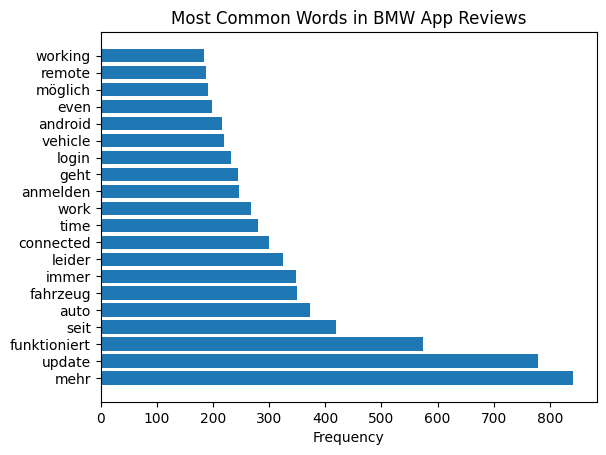

In [112]:
import matplotlib.pyplot as plt

common_words = Counter(filtered_words).most_common(20)
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.barh(words, counts)
plt.xlabel("Frequency")
plt.title("Most Common Words in BMW App Reviews")
plt.show()

##### Nun installieren wir zunächst wordcloud (pip install wordcloud)

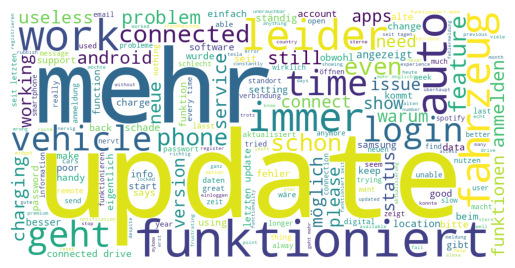

In [114]:
from wordcloud import WordCloud

text= " ".join(filtered_words)
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

##### Wir schauen uns jetzt nochmal die Rating Distribution und die Review Length Distribution an. Also Wie viele Reviews sind 1 Stern, 2 Sterne, 3 Sterne, 4 Sterne, 5 Sterne? Daraus sehen wir wie zufrieden die Nutzer sind. Und Kurze Reviews vs lange Problemberichte.

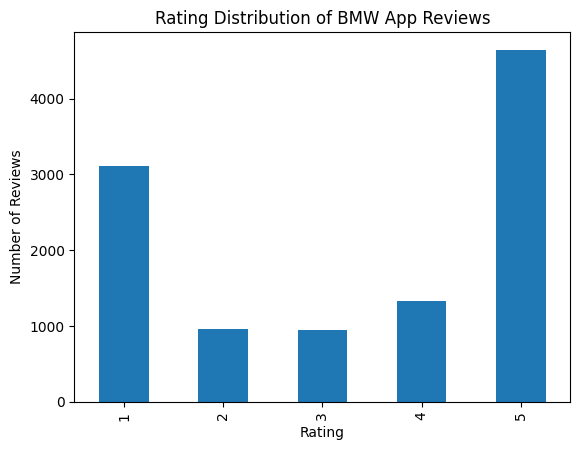

In [115]:
import matplotlib.pyplot as plt
df["score"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution of BMW App Reviews")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

##### Wir sehen zwar dass der größte teil der Nutzer mit der App zufrieden ist allerdings ist die Anzahl der unzufriedenen Nutzer ebenfalls hoch mit über 4000 reviews.

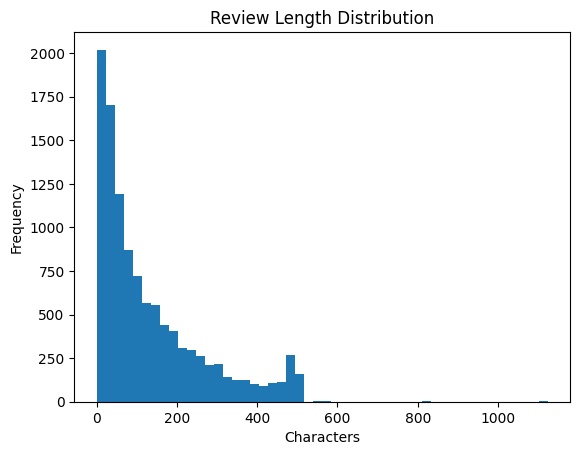

In [116]:
df["review_length"]= df["content"].str.len()
plt.hist(df["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

##### In dem Diagramm oben sehen wir dass eine stark rechtsschiefe Verteilung vorliegt. Das bedeutet, dass viele kurze Reviews und wenige lange Reviews vorhanden sind. Dies ist üblich für app reviews da Nutzer oftmals nur kurz ihre Meinung hinterlassen statt lange Problemberichte.

##### Nachfolgend schauen wir uns die most negative words an. Hierzu filtern wir nach 2 oder weniger Sternen und schauen uns dort die häufigsten Wörter an.

In [117]:
negative_reviews = df[df["score"] <= 2]["content"]
text= " ".join(negative_reviews)
words=re.findall(r"\b[a-zA-ZäöüÄÖÜ]+\b",text.lower())
negative_words= [word for word in words if word not in stop_words and len(word)>3]
Counter(negative_words).most_common(20)

[('mehr', 841),
 ('update', 779),
 ('funktioniert', 574),
 ('seit', 419),
 ('auto', 372),
 ('fahrzeug', 350),
 ('immer', 348),
 ('leider', 324),
 ('connected', 299),
 ('time', 280),
 ('work', 268),
 ('anmelden', 246),
 ('geht', 245),
 ('login', 233),
 ('vehicle', 219),
 ('android', 216),
 ('even', 198),
 ('möglich', 192),
 ('remote', 188),
 ('working', 184)]

##### Die Key Insights aus dem EDA
- Die meisten reviews nennen Probleme mit login, connectivity und update.
- Negative reviews erwähnen überwiegend "login", "update", "connection".
- Reviews sind meistens kurz formuliert.
- Die Anzahl der 1 Sterne Rating ist relativ hoch.

##### Zusätzlich ergänzen wir zu unserem EDA die Zeitverlauf Analyse unter Berücksichtigung der Updates.Hierzu nutzen wir die aus dem preprocessing bereinigten Daten.

In [121]:
df = pd.read_csv("../data/BMW/preprocessed_reviews.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10509 entries, 0 to 10508
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              10509 non-null  object
 1   content               10509 non-null  object
 2   score                 10509 non-null  int64 
 3   thumbsUpCount         10509 non-null  int64 
 4   reviewCreatedVersion  9953 non-null   object
 5   at                    10509 non-null  object
 6   appVersion            9953 non-null   object
 7   company               10509 non-null  object
 8   clean_text            10498 non-null  object
 9   tokens                10509 non-null  object
 10  lemmatized_text       10498 non-null  object
dtypes: int64(2), object(9)
memory usage: 903.2+ KB


##### Im ersten Schritt schauen wir uns den Review Zeitverlauf an

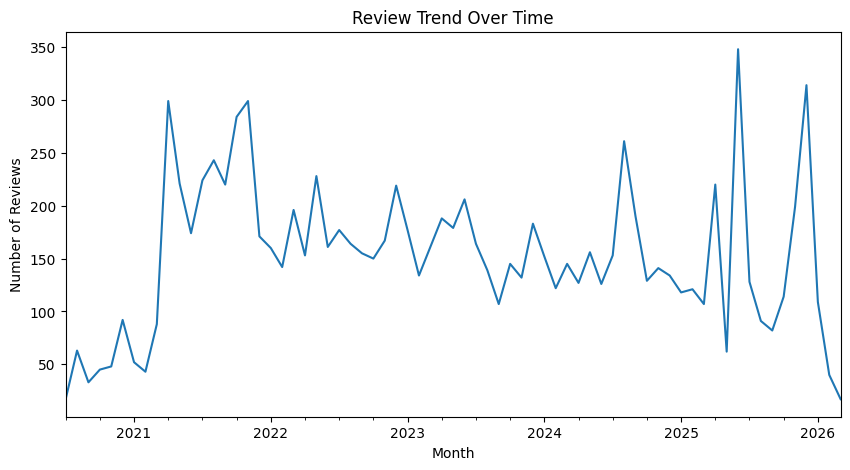

In [122]:
df["at"]=pd.to_datetime(df["at"])
reviews_per_month=df.groupby(df["at"].dt.to_period("M")).size()
reviews_per_month.plot(figsize=(10,5))
plt.title("Review Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.show()

##### Im zweiten Schritt analysieren wir die Versionen

In [123]:
#Reviews pro App Version analysieren. Wie oft kommt jede Version vor?
df["appVersion"].value_counts()

appVersion
1.6.2     428
3.3.1     367
4.7.3     352
1.5.2     335
2.7.0     321
         ... 
3.11.4      2
3.11.0      1
5.11.5      1
5.11.0      1
4.3.0       1
Name: count, Length: 102, dtype: int64

In [132]:
#Reviews sortiert nach Zeit 
df.groupby("appVersion")["at"].min().sort_values()

appVersion
1.0.0    2020-07-27 15:47:02
1.0.1    2020-09-08 23:36:40
1.1.0    2020-10-12 21:04:02
1.2.0    2020-11-30 18:05:18
1.2.1    2020-12-08 09:59:34
                 ...        
5.11.1   2025-11-21 14:12:50
5.11.2   2025-12-01 18:14:32
5.11.3   2025-12-04 19:05:16
5.11.4   2026-01-26 22:20:15
5.11.5   2026-03-02 18:50:10
Name: at, Length: 102, dtype: datetime64[ns]

In [125]:
#Durchschnittliche Rating pro Version
df.groupby("appVersion")["score"].mean().sort_values()

appVersion
2.9.0     1.750000
5.9.0     1.818182
1.3.3     1.892857
5.9.1     2.000000
1.3.2     2.287129
            ...   
4.7.2     4.528302
4.7.0     5.000000
3.11.4    5.000000
4.3.0     5.000000
3.11.0    5.000000
Name: score, Length: 102, dtype: float64

In [126]:
#Durchschnittliches Rating pro Monat
rating_over_time= df.set_index("at").resample("M")["score"].mean()

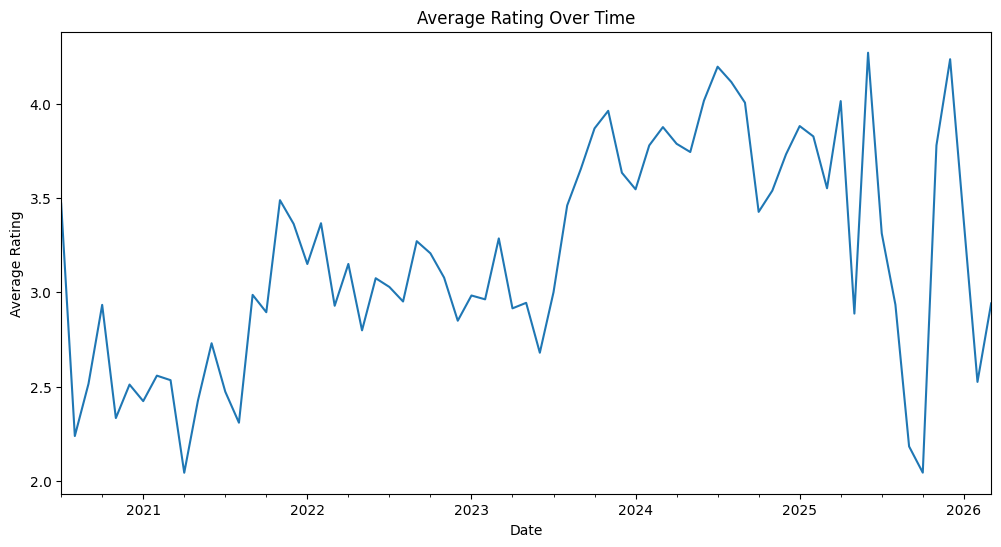

In [127]:
#Plot erstellen
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
rating_over_time.plot()
plt.title("Average Rating Over Time")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.show()

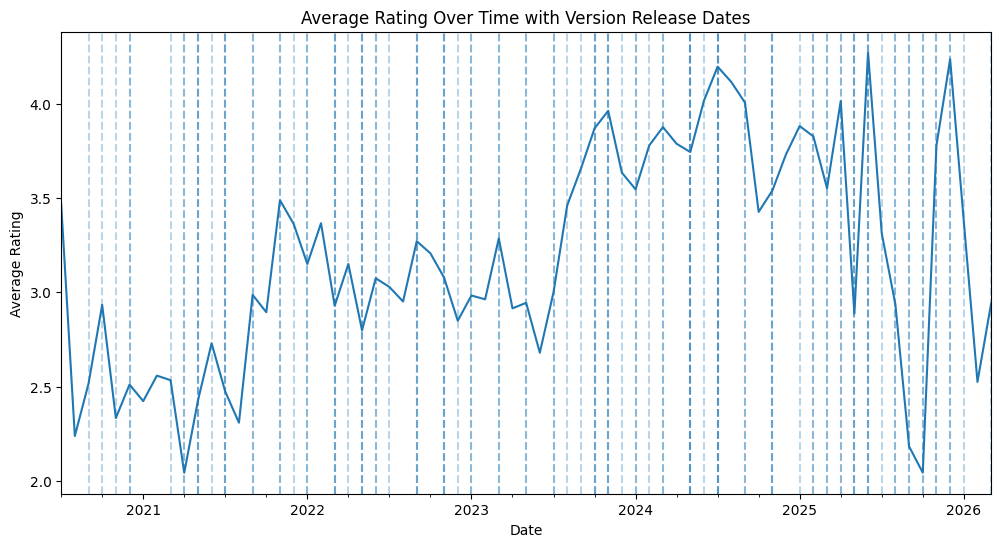

In [128]:
#Jetzt markieren wir erste Reviews einer Version
verion_dates= df.groupby("appVersion")["at"].min().sort_values()
plt.figure(figsize=(12,6))
rating_over_time.plot()
for date in verion_dates:
    plt.axvline(date, linestyle="--", alpha=0.3)

plt.title("Average Rating Over Time with Version Release Dates")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.show()

##### Wir haben festgestellt, dass jedes Update unterschiedlcihe Anzahl an Revies hat. Dies würde zu unplausiblen Auswertungen führen, da ein Update mit nur 1 Review nicht gleichzusetzen ist mit einem Update mit >=50 Reviews.Demzufolge entfernen wir Versionen mit sehr wenigen Reviews. Eine gute wissenschaftliche Regel für stabile Aussagen ist mindestens 30-50 Reviews pro Version. 

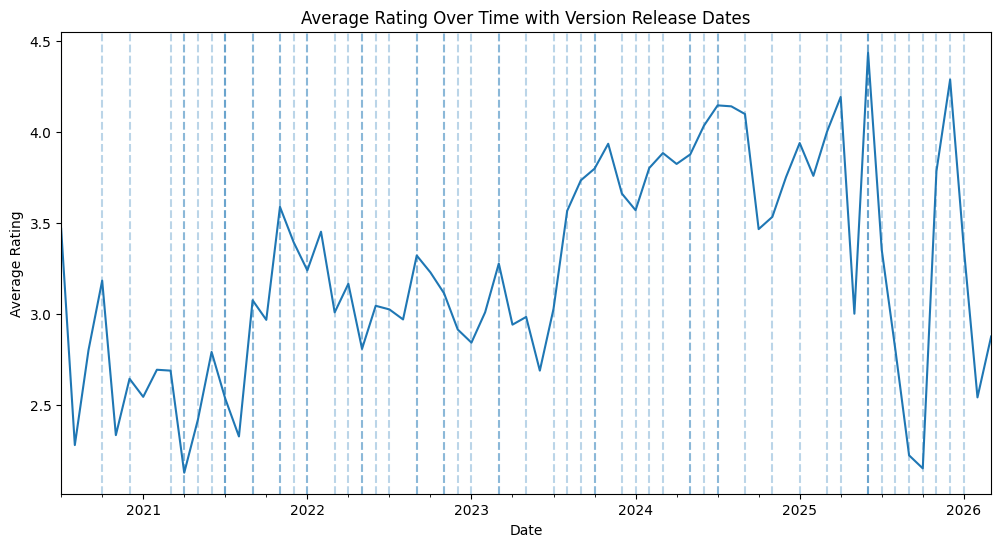

In [136]:
version_counts=df["appVersion"].value_counts()
valid_versions= version_counts[version_counts>50].index
df_filtered=df[df["appVersion"].isin(valid_versions)]

#Jetzt markieren wir erste Reviews einer Version
rating_over_time= df_filtered.set_index("at").resample("M")["score"].mean()
version_dates= df_filtered.groupby("appVersion")["at"].min().sort_values()
plt.figure(figsize=(12,6))
rating_over_time.plot()
for date in version_dates:
    plt.axvline(date, linestyle="--", alpha=0.3)

plt.title("Average Rating Over Time with Version Release Dates")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.show()

In [135]:
df_filtered["appVersion"].value_counts()

appVersion
1.6.2    428
3.3.1    367
4.7.3    352
1.5.2    335
2.7.0    321
        ... 
1.5.1     53
4.7.2     53
5.7.1     53
1.7.3     51
4.5.1     51
Name: count, Length: 62, dtype: int64

In [138]:
df_filtered.shape

(9086, 11)

## Verbesserte Version der Explorativen Datenanalyse (Vorschlag Co-Pilot)

Basierend auf der fachlichen Bewertung habe ich eine modularisierte und robustere Version erstellt. Diese umfasst:

- **Modulare Struktur**: Logische Abschnitte mit Kommentaren
- **Validierungen**: Assert-Statements und Logging für Datenintegrität
- **Statistische Tests**: Signifikanzprüfungen zwischen Versionen
- **Verbesserte Visualisierungen**: Seaborn für bessere Ästhetik
- **Automatisierte Zusammenfassung**: Key Insights werden berechnet
- **Fehlerbehandlung**: Try-Except um kritische Operationen